In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import math
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
#import plotly.express as px
#import plotly.graph_objects as go
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
from torchvision import transforms
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F

In [2]:
from transformers import AutoFeatureExtractor, SwinForImageClassification, SwinConfig, AutoModel, AutoImageProcessor, get_scheduler
from transformers import ViTImageProcessor, ViTForImageClassification, EfficientNetModel, EfficientNetForImageClassification,EfficientNetConfig
from PIL import Image
import requests
from torch.optim import AdamW
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.model_selection import KFold, StratifiedKFold

2026-03-19 06:31:46.181684: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773901906.359581      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773901906.411636      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773901906.883010      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773901906.883054      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773901906.883056      24 computation_placer.cc:177] computation placer alr

In [3]:
if torch.cuda.is_available():
    print("GPU is available!")
else:
    print("GPU is not available.")

GPU is available!


import torch_xla
import torch_xla.core.xla_model as xm
device = xm.xla_device()
torch.set_default_tensor_type('torch.FloatTensor')

In [4]:
root_dir = "/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset"

classes = sorted(os.listdir(root_dir))
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
file_paths = []
labels = []
#for filename in os.listdir(image_folder):
#    if filename.endswith(".jpg") or filename.endswith(".png"):  # Modify based on your image extensions
#        file_paths.append(os.path.join(image_folder, filename))
#        isicid=filename.split(".")[0]
#        labels.append(labels_dict[isicid])
        
for cls in classes:
    cls_path = os.path.join(root_dir, cls)
    for img_name in os.listdir(cls_path):
        file_paths.append(os.path.join(cls_path, img_name))
        labels.append(class_to_idx[cls])

In [5]:
#labels

In [6]:
class_to_idx

{'MildDemented': 0,
 'ModerateDemented': 1,
 'NonDemented': 2,
 'VeryMildDemented': 3}

In [7]:
class MRIdata(Dataset):
    def __init__(self, file_paths, labels, transform=None,device='cpu'):
        self.paths = file_paths
        self.dlabels = labels
        self.transform = transform
        self.device= device

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        x = Image.open(path).convert("RGB")
        x = x.resize((300,300))
        x = np.array(x)
        y = self.dlabels[idx]
        y=np.array(y)
        if self.transform:
            x = self.transform(x)
        #x=torch.from_numpy(x).to('cuda')
        #y=torch.from_numpy(y).to('cuda')
        #x = x.to(self.device)
        #y = torch.tensor(y, dtype=torch.long).to(self.device)
        #x = x.to('cuda')
        #y = y.to('cuda')
        #feature_extractor = AutoImageProcessor.from_pretrained("google/efficientnet-b3",do_rescale=False)
        #x=feature_extractor(images=x, return_tensors="pt")
        return x, y

# Define transformations
data_transforms = v2.Compose([
    v2.Resize(300),
    #v2.RandomHorizontalFlip(p=0.5),
    #v2.RandomVerticalFlip(p=0.5),
    #v2.ColorJitter(brightness=(0.5,1.5), contrast=1.0, saturation=(0.5,1.5), hue=(-0.1,0.1)),
    #v2.RandomRotation(degrees=(0, 180)),
    #v2.RandomAdjustSharpness(sharpness_factor=10, p=0.5),
    v2.ToDtype(torch.float32)
    #v2.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406],
    #                    std=[0.229, 0.224, 0.225])
])

# Create dataset with transformations
dataset = MRIdata(file_paths, labels, transform=data_transforms, device='cuda')

In [8]:
#ab

from torch.utils.data import DataLoader
from transformers import EfficientNetModel, AutoImageProcessor
import numpy as np
import torch

device = "cuda"

loader = DataLoader(dataset, batch_size=32, shuffle=False)

efficientnet = EfficientNetModel.from_pretrained("google/efficientnet-b3").to(device)
processor = AutoImageProcessor.from_pretrained("google/efficientnet-b3", do_rescale=False)

efficientnet.eval()

features = []
labels_list = []

with torch.no_grad():
    
    for x, y in loader:
        
        x = x.to(device)

        imgs = processor(images=x, return_tensors="pt").to(device)

        out = efficientnet(imgs['pixel_values']).pooler_output
        
        features.append(out.cpu().numpy())
        labels_list.append(y.numpy())

X = np.vstack(features)
y = np.concatenate(labels_list)

print(X.shape)   # (N,1536)
print(y.shape)

In [9]:
import numpy as np
from PIL import Image

images = []
labels_list = []

for path, label in zip(file_paths, labels):

    img = Image.open(path).convert("RGB")
    img = img.resize((128,128))

    img = np.array(img).astype(np.float32) / 255.0   # convert to float

    images.append(img.flatten())                     # flatten
    labels_list.append(label)

X = np.array(images)
y = np.array(labels_list)

print(X.shape)

(6400, 49152)


In [10]:
images[0].shape

(49152,)

In [11]:
128*128*3

49152

from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_smote,
    y_smote,
    test_size=0.2,
    stratify=y_smote,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    stratify=y_train_val,
    random_state=42
)

In [12]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)

X_smote, y_smote = adasyn.fit_resample(X, y)

print("Before:", np.bincount(y))
print("After:", np.bincount(y_smote))

Before: [ 896   64 3200 2240]
After: [3184 3199 3200 3170]


from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)

print("Before:", np.bincount(y))
print("After:", np.bincount(y_smote))

In [13]:
X_images = X_smote.reshape(-1, 128, 128, 3)

print(X_images.shape)

(12753, 128, 128, 3)


In [14]:
import torch
from torch.utils.data import Dataset

class SMOTEImageDataset(Dataset):

    def __init__(self, images, labels):

        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = self.images[idx].permute(2,0,1)   # HWC → CHW
        label = self.labels[idx]

        return img, label

In [15]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_images, y_smote,
    test_size=0.2,
    stratify=y_smote,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    stratify=y_train_val,
    random_state=42
)

class FeatureDataset(torch.utils.data.Dataset):

    def __init__(self, features, labels):

        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [16]:
train_dataset = SMOTEImageDataset(X_train, y_train)
val_dataset   = SMOTEImageDataset(X_val, y_val)
test_dataset  = SMOTEImageDataset(X_test, y_test)

In [17]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [18]:
#image, labelsingle = FeatureDataset
#image_np = image.numpy().transpose((1, 2, 0))
#image_np = np.array(image)

In [19]:
#image_np.shape

In [20]:
#plt.imshow(image_np)

In [21]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.feature_extractor = AutoImageProcessor.from_pretrained("google/efficientnet-b3",do_rescale=False)
        self.model = EfficientNetModel.from_pretrained("google/efficientnet-b3")
        # Define the custom dense layers
        self.fc1 = nn.Linear(1536, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 4)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        
    def forward(self, x):
        # Extract features using Swin Transformer
        imgs = self.feature_extractor(images=x, return_tensors="pt").to("cuda")
        out = self.model(imgs['pixel_values']).pooler_output.to("cuda")
        #pooled_output = features.last_hidden_state.mean(dim=1)
        
        # Pass the features through custom dense layers
        #x = self.fc1(pooled_output)
        x = self.fc1(out)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.relu(x)
        
        # Apply sigmoid activation for binary classification
        #x = self.sigmoid(x)
        
        return x

In [22]:
model=Classifier()

preprocessor_config.json:   0%|          | 0.00/495 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/49.5M [00:00<?, ?B/s]

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [24]:
model=model.to(device)

In [25]:
class CostSensitiveLossFN(nn.Module):

    def __init__(self, cost_matrix, lambda_fnr=1.0):
        super().__init__()

        self.register_buffer(
            "cost_matrix",
            torch.tensor(cost_matrix, dtype=torch.float32)
        )

        self.lambda_fnr = lambda_fnr


    def forward(self, logits, targets):

        probs = F.softmax(logits, dim=1)

        ce_loss = F.cross_entropy(logits, targets)

        cost_rows = self.cost_matrix[targets]

        cost_penalty = torch.sum(probs * cost_rows, dim=1).mean()

        preds = torch.argmax(probs, dim=1)

        disease_mask = (targets != 2)
        predicted_healthy = (preds == 2)

        fn = (disease_mask & predicted_healthy).float().sum()

        positives = disease_mask.float().sum()

        fnr = fn / (positives + 1e-8)

        loss = ce_loss + cost_penalty + self.lambda_fnr * fnr

        return loss

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TPRSensitiveLoss(nn.Module):

    def __init__(self, cost_matrix, lambda_tpr=1.0):
        super().__init__()

        # Automatically moves to GPU
        self.register_buffer(
            "cost_matrix",
            torch.tensor(cost_matrix, dtype=torch.float32)
        )

        self.lambda_tpr = lambda_tpr


    def forward(self, logits, targets):

        probs = F.softmax(logits, dim=1)

        ce_loss = F.cross_entropy(logits, targets)

        cost_rows = self.cost_matrix[targets]

        cost_penalty = torch.sum(probs * cost_rows, dim=1).mean()

        preds = torch.argmax(probs, dim=1)

        disease_mask = targets != 2
        predicted_disease = preds != 2

        tp = (disease_mask & predicted_disease).float().sum()

        positives = disease_mask.float().sum()

        tpr = tp / (positives + 1e-8)

        loss = ce_loss + cost_penalty - self.lambda_tpr * tpr

        return loss

In [27]:
#((preds != targets) & (preds > targets)).float().sum()
#(targets != 2)

In [28]:
a=5
cost_matrix = torch.tensor([
[0,     1,    a*2,    1],   # True Mild
[1,     0,    a*3,    2],   # True Moderate
[0.5,   0.33,    0,    1],   # True ND
[1,     0.5,    a*1,    0]    # True VeryMild 
], dtype=torch.float32)

In [29]:
cost_matrix = (cost_matrix - cost_matrix.min()) / (cost_matrix.max() - cost_matrix.min()) #min-max normalization

In [30]:
cost_matrix

tensor([[0.0000, 0.0667, 0.6667, 0.0667],
        [0.0667, 0.0000, 1.0000, 0.1333],
        [0.0333, 0.0220, 0.0000, 0.0667],
        [0.0667, 0.0333, 0.3333, 0.0000]])

In [31]:
batch=16
learning_rate=1e-5

#lossf=nn.BCELoss()
lossf=nn.CrossEntropyLoss()
#criterion= CostSensitiveLossFN(cost_matrix).to(device)
#lossf= TPRSensitiveLoss(cost_matrix).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
#optimizer=AdamW(model.parameters(), lr=1e-5)
num_epochs=25

scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,patience=3)

In [32]:
from tqdm import tqdm

In [33]:
for param in model.parameters():
    param.requires_grad = True

In [34]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                print("patience=",self.patience)
                return True
        return False

In [35]:
early_stopper = EarlyStopper(patience=5, min_delta=5)

In [36]:
from torch.cuda.amp import autocast, GradScaler

In [37]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [38]:
#labels

In [39]:
data_iter = iter(train_loader)
try:
    features, labels = next(data_iter)
    print(f"Batch features shape: {features.shape}")
    print(f"Batch labels shape: {labels.shape}")

except StopIteration:
    print("The dataloader is empty or has been fully iterated.")


Batch features shape: torch.Size([32, 3, 128, 128])
Batch labels shape: torch.Size([32])


In [40]:
#ab

labels_np = np.array(labels)
fold_loaders = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels_np)), labels_np)):
    print(f"\nFold {fold+1}")

    train_subset = Subset(SMOTEImageDataset, train_idx)
    val_subset   = Subset(SMOTEImageDataset, val_idx)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch,
        shuffle=False,
        num_workers=0
    )

    fold_loaders.append((train_loader, val_loader))

In [41]:
#ab

In [42]:
saved_outputs=[]
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []
best_accuracy=0
best_loss=0

#for fold, (train_loader, val_loader) in enumerate(fold_loaders):
#    print(f"\nTraining Fold {fold+1}/{n_splits}")
    
for epoch in range(num_epochs):
    train_loss = 0.0
    train_acc = 0.0
    val_loss = 0.0
    val_acc = 0.0
    correct_predictions = 0
    total_predictions = 0
    vcorrect_predictions = 0
    vtotal_predictions = 0
    model.train()
    train_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}")
    for (inputs, labels) in train_bar:
        inputs, labelsgpu = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs=model(inputs)
        outputscpu=outputs.to('cpu')
        loss = lossf(outputs, labelsgpu)
        nplabels=labels.detach()
        nplabels=nplabels.numpy()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        nptrainout=outputscpu.detach()
        nptrainout=nptrainout.numpy()
        nplabels=nplabels>0
        preds = outputs.argmax(dim=1)
        correct_predictions += (preds == labelsgpu.int()).sum().item()
        total_predictions += labels.size(0)

        train_bar.set_postfix(
            loss=train_loss / (total_predictions),
            acc=correct_predictions / total_predictions
        )
        
    train_loss /= len(train_loader)
    train_loss_history.append(train_loss)
    #train_acc /= len(train_loader.dataset)
    train_acc =correct_predictions / total_predictions
    train_acc_history.append(train_acc)
    
    # set the model to evaluation mode
    model.eval()
    val_bar = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{num_epochs}")
    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs, labelsgpu = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            outputscpu=outputs.to('cpu')
            nplabels=labels.detach()
            nplabels=nplabels.numpy()
            vloss = lossf(outputs, labelsgpu)
            val_loss += vloss.item()
            npvalout=outputscpu.detach()
            nptrainout=npvalout.numpy()
            nplabels=nplabels>0
            preds = outputs.argmax(dim=1)
            vcorrect_predictions += (preds == labelsgpu).sum().item()
            vtotal_predictions += labels.size(0)
    val_acc =vcorrect_predictions / vtotal_predictions
    if (val_acc > best_accuracy):
        best_accuracy = val_acc
        torch.save(model.state_dict(),'checkpoint_best_val_acc.sav')
        print(f'Saving best model with validation accuracy: {best_accuracy:.4f}')
    scheduler.step(vloss.item())        
    val_loss /= len(val_loader)
    if early_stopper.early_stop(val_loss):
        print("Lower val_Loss of", val_loss)
        break
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    

    print(f'Epoch {epoch+1}/{num_epochs}, train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f}')
    saved_outputs.append((epoch,outputs))


Validation Epoch 1/25: 100%|██████████| 64/64 [00:16<00:00,  3.82it/s]


Saving best model with validation accuracy: 0.5512
Epoch 1/25, train loss: 1.0801, train acc: 0.5308, val loss: 1.1571, val acc: 0.5512


Validation Epoch 2/25: 100%|██████████| 64/64 [00:17<00:00,  3.69it/s]


Saving best model with validation accuracy: 0.5644
Epoch 2/25, train loss: 0.7619, train acc: 0.6864, val loss: 1.0780, val acc: 0.5644


Validation Epoch 3/25: 100%|██████████| 64/64 [00:17<00:00,  3.67it/s]


...

Epoch 23/25, train loss: 0.0695, train acc: 0.9775, val loss: 874.0528, val acc: 0.2239


Validation Epoch 24/25: 100%|██████████| 64/64 [00:17<00:00,  3.56it/s]


Epoch 24/25, train loss: 0.0693, train acc: 0.9800, val loss: 1.2970, val acc: 0.6742


Validation Epoch 25/25: 100%|██████████| 64/64 [00:17<00:00,  3.62it/s]

Epoch 25/25, train loss: 0.0794, train acc: 0.9782, val loss: 0.8109, val acc: 0.7305


In [43]:
inputs, labelsgpu = inputs.to(device), labels.to(device)

In [44]:
inputs.shape

torch.Size([25, 3, 128, 128])

In [45]:
outputs=model(inputs)

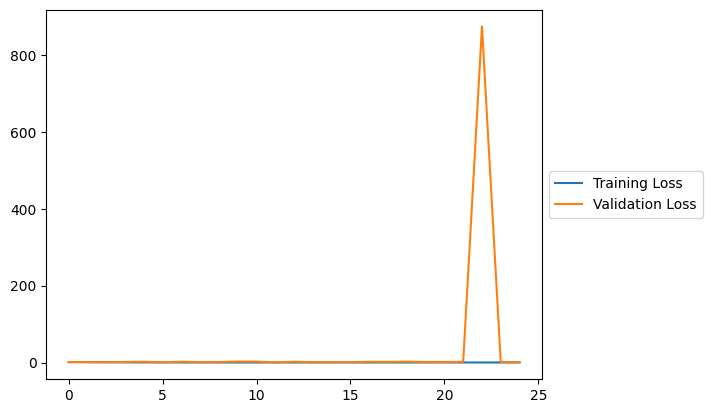

In [46]:
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history,label='Validation Loss')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

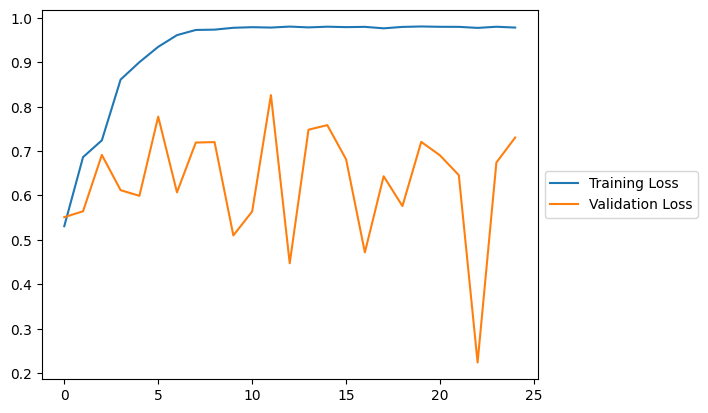

In [47]:
plt.plot(train_acc_history, label='Training Loss')
plt.plot(val_acc_history,label='Validation Loss')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [48]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [49]:
#model.load_state_dict(torch.load("/kaggle/input/models/therealarnab/cs70-norm/pytorch/default/1/cost_sensitiveFN70norm.sav"))

test_idx= torch.load(
    "/kaggle/input/datasets/therealarnab/mri-test/test_idx.pt",
    weights_only=False
)
test_dataset = Subset(dataset, test_idx)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [50]:
test_probs = []
test_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)                      # logits
        probs = torch.softmax(outputs, dim=1)       # [B, C]

        #for i in labels:
         #   if(i==1):
          #      print(probs.argmax(axis=1))

        test_probs.append(probs.cpu())
        test_labels.append(labels.cpu())

test_probs = torch.cat(test_probs).numpy()
test_labels = torch.cat(test_labels).numpy()

In [51]:
pred_labels= test_probs.argmax(axis=1)

In [52]:
test_probs

array([[1.0823518e-03, 9.9889010e-01, 1.3787027e-05, 1.3787027e-05],
       [8.8103843e-01, 3.9653864e-02, 3.9653864e-02, 3.9653864e-02],
       [9.9999988e-01, 4.2454271e-08, 4.2454271e-08, 4.2454271e-08],
       ...,
       [1.8749928e-01, 2.0803154e-01, 4.4402438e-01, 1.6044487e-01],
       [2.1151297e-02, 1.0448407e-02, 9.6097296e-01, 7.4272361e-03],
       [1.1863036e-07, 9.9999988e-01, 7.0135946e-09, 7.0135946e-09]],
      dtype=float32)

In [53]:
pred_labels

array([1, 0, 0, ..., 2, 2, 1])

In [54]:
test_labels

array([1, 2, 0, ..., 3, 2, 1])

In [55]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [56]:
classes = [0,1,2,3]

y_test_bin = label_binarize(test_labels, classes=classes)

In [57]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(4):
    
    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        test_probs[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

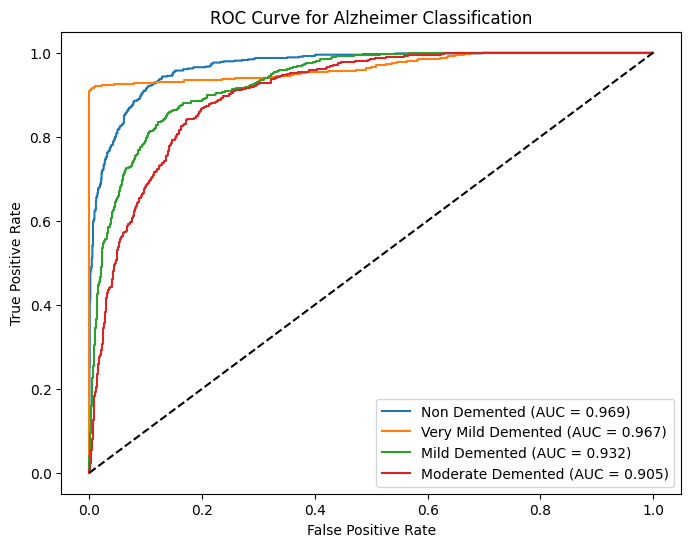

In [58]:
plt.figure(figsize=(8,6))

class_names = [
    "Non Demented",
    "Very Mild Demented",
    "Mild Demented",
    "Moderate Demented"
]

for i in range(4):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Alzheimer Classification")

plt.legend()
plt.show()

In [59]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(
    y_test_bin,
    test_probs,
    multi_class='ovr',
    average='macro'
)

print("Macro AUC:", macro_auc)

Macro AUC: 0.9430802179214335


In [60]:
for i,j in enumerate(pred_labels):
    if (j==1):
        print(i,j)

0 1
4 1
5 1
7 1
9 1
13 1
16 1
19 1
23 1
24 1
26 1
27 1
28 1
44 1
47 1
53 1
54 1
66 1
68 1
70 1
71 1
74 1
79 1
80 1
81 1
82 1
84 1
86 1
97 1
100 1
109 1
117 1
119 1
121 1
123 1
128 1
149 1
150 1
153 1
160 1
161 1
166 1
170 1
171 1
174 1
178 1
182 1
187 1
190 1
192 1
194 1
199 1
213 1
214 1
215 1
218 1
220 1
235 1
249 1
250 1
260 1
264 1
269 1
271 1
272 1
275 1
277 1
279 1
280 1
281 1
282 1
288 1
291 1
297 1
312 1
313 1
327 1
331 1
345 1
350 1
352 1
357 1
361 1
366 1
376 1
379 1
381 1
389 1
391 1
395 1
401 1
411 1
414 1
415 1
422 1
423 1
426 1
446 1
450 1
455 1
463 1
464 1
474 1
475 1
476 1
481 1
483 1
487 1
488 1
505 1
509 1
511 1
512 1
514 1
518 1
528 1
530 1
533 1
536 1
537 1
545 1
547 1
555 1
557 1
562 1
571 1
572 1
574 1
583 1
585 1
589 1
593 1
596 1
600 1
601 1
602 1
608 1
614 1
616 1
618 1
622 1
623 1
629 1
632 1
642 1
646 1
647 1
649 1
654 1
657 1
662 1
666 1
692 1
694 1
695 1
696 1
697 1
699 1
710 1
711 1
715 1
720 1
722 1
724 1
726 1
728 1
729 1
730 1
736 1
739 1
746 1
773 1
77

In [61]:
accuracy = np.mean(pred_labels == test_labels)

In [62]:
accuracy

np.float64(0.7322618580948648)

In [63]:
(pred_labels == test_labels).sum() / len(test_labels)

np.float64(0.7322618580948648)

In [64]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels,pred_labels)

In [65]:
cm

array([[618,   1,  14,   4],
       [ 57, 582,   0,   1],
       [ 95,   1, 519,  25],
       [270,  10, 205, 149]])

In [66]:
from sklearn.metrics import precision_recall_fscore_support as score
precision, recall, fscore, support = score(test_labels,pred_labels)

In [67]:
print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))

precision: [0.59423077 0.97979798 0.70325203 0.83240223]
recall: [0.97017268 0.909375   0.8109375  0.23501577]
fscore: [0.73703041 0.94327391 0.7532656  0.36654367]
support: [637 640 640 634]


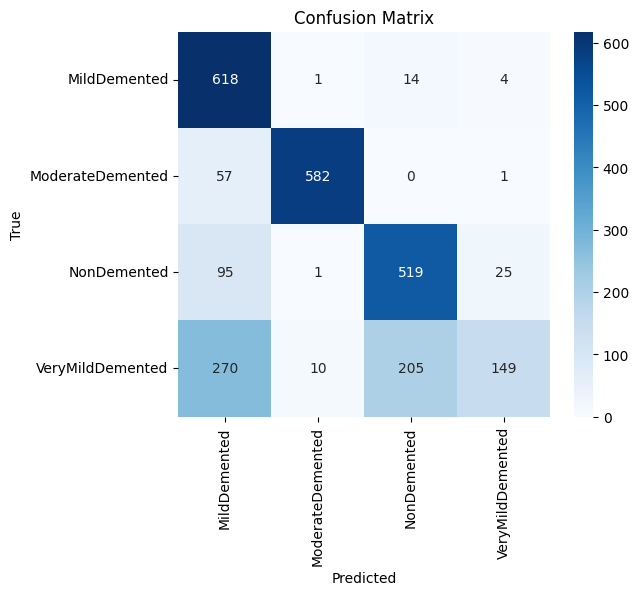

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_to_idx,
    yticklabels=class_to_idx
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [69]:
pred_labels = np.array(pred_labels)
test_labels = np.array(test_labels)

# disease cases (true dementia)
disease_mask = test_labels != 2

# predicted healthy
predicted_healthy = pred_labels == 2

false_negatives = np.sum(disease_mask & predicted_healthy)

print("False Negatives:", false_negatives)

False Negatives: 219


In [70]:
for i in range(len(pred_labels)):
    if pred_labels[i] == 2 and test_labels[i] != 2:
        print(i, pred_labels[i], test_labels[i])

22 2 3
46 2 3
55 2 3
59 2 3
62 2 3
64 2 3
75 2 3
78 2 3
111 2 3
131 2 3
136 2 3
148 2 3
152 2 3
155 2 3
163 2 3
167 2 3
179 2 3
188 2 3
198 2 3
200 2 3
206 2 3
209 2 3
226 2 3
234 2 3
270 2 3
284 2 3
289 2 3
309 2 3
333 2 3
348 2 3
362 2 3
377 2 3
383 2 0
385 2 3
399 2 3
412 2 3
418 2 3
436 2 3
441 2 3
467 2 3
469 2 0
471 2 3
473 2 3
500 2 3
506 2 3
510 2 3
532 2 3
563 2 3
576 2 3
588 2 3
607 2 3
617 2 3
636 2 3
661 2 3
683 2 3
684 2 0
687 2 3
707 2 3
718 2 3
731 2 3
745 2 3
750 2 3
757 2 3
782 2 3
814 2 3
835 2 3
838 2 3
844 2 3
855 2 3
856 2 3
901 2 3
905 2 3
906 2 3
907 2 3
908 2 0
910 2 3
926 2 3
936 2 0
937 2 3
948 2 3
962 2 3
963 2 3
965 2 3
972 2 3
975 2 3
976 2 3
1011 2 3
1021 2 3
1030 2 3
1041 2 3
1052 2 3
1053 2 3
1064 2 3
1065 2 3
1108 2 3
1119 2 3
1126 2 3
1195 2 3
1218 2 3
1222 2 3
1253 2 3
1267 2 3
1276 2 3
1280 2 0
1324 2 3
1328 2 3
1338 2 3
1359 2 3
1368 2 3
1371 2 3
1377 2 3
1392 2 0
1410 2 3
1413 2 3
1417 2 3
1422 2 3
1436 2 3
1461 2 3
1467 2 3
1470 2 3
1471 2 3
1479 

In [71]:
torch.save(train_idx, "train_idx.pt")
torch.save(test_idx, "test_idx.pt")
#torch.save(val_idx, "val_idx.pt")

NameError: name 'train_idx' is not defined